In [1]:
# =====================================================
# ASSIGNMENT 2 - Data Wrangling II
# Dataset: Academic Performance (Created manually)
# =====================================================


In [2]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# =====================================================
# STEP 2: Create the Dataset
# =====================================================
data = {
    'Name':       ['Alice', 'Bob', 'Charlie', 'David', 'Eva',
                   'Frank', 'Grace', 'Henry', 'Isla', 'Jake'],
    'Age':        [20, 21, np.nan, 22, 20, 23, np.nan, 21, 22, 20],
    'Marks':      [85, 90, 78, 200, 88, 76, 95, np.nan, 80, 92],
    'Attendance': [90, 85, np.nan, 88, 92, 78, 95, 80, np.nan, 88],
    'StudyHours': [5, 6, 4, 7, 5, np.nan, 8, 4, 6, 7],
    'Grade':      ['A', 'A', 'B', 'A', 'A', 'B', 'A', np.nan, 'B', 'A']
}


In [6]:
df = pd.DataFrame(data)

In [7]:
print("Original Dataset:")
print(df)

Original Dataset:
      Name   Age  Marks  Attendance  StudyHours Grade
0    Alice  20.0   85.0        90.0         5.0     A
1      Bob  21.0   90.0        85.0         6.0     A
2  Charlie   NaN   78.0         NaN         4.0     B
3    David  22.0  200.0        88.0         7.0     A
4      Eva  20.0   88.0        92.0         5.0     A
5    Frank  23.0   76.0        78.0         NaN     B
6    Grace   NaN   95.0        95.0         8.0     A
7    Henry  21.0    NaN        80.0         4.0   NaN
8     Isla  22.0   80.0         NaN         6.0     B
9     Jake  20.0   92.0        88.0         7.0     A


In [8]:
# =====================================================
# STEP 3: Check for Missing Values and Inconsistencies
# =====================================================
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Name          0
Age           2
Marks         1
Attendance    2
StudyHours    1
Grade         1
dtype: int64


In [9]:
# Fix inconsistency: Marks = 200 is impossible (max should be 100)
print("\nInconsistency found: Marks = 200 (impossible value), replacing with median")
df['Marks'] = df['Marks'].replace(200, np.nan)


Inconsistency found: Marks = 200 (impossible value), replacing with median


In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Marks'] = df['Marks'].fillna(df['Marks'].median())
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())
df['StudyHours'] = df['StudyHours'].fillna(df['StudyHours'].median())
df['Grade'] = df['Grade'].fillna(df['Grade'].mode()[0])

In [11]:
print("\nAfter Handling Missing Values:")
print(df)
print("\nMissing Values After Fix:")
print(df.isnull().sum())


After Handling Missing Values:
      Name   Age  Marks  Attendance  StudyHours Grade
0    Alice  20.0   85.0        90.0         5.0     A
1      Bob  21.0   90.0        85.0         6.0     A
2  Charlie  21.0   78.0        88.0         4.0     B
3    David  22.0   86.5        88.0         7.0     A
4      Eva  20.0   88.0        92.0         5.0     A
5    Frank  23.0   76.0        78.0         6.0     B
6    Grace  21.0   95.0        95.0         8.0     A
7    Henry  21.0   86.5        80.0         4.0     A
8     Isla  22.0   80.0        88.0         6.0     B
9     Jake  20.0   92.0        88.0         7.0     A

Missing Values After Fix:
Name          0
Age           0
Marks         0
Attendance    0
StudyHours    0
Grade         0
dtype: int64


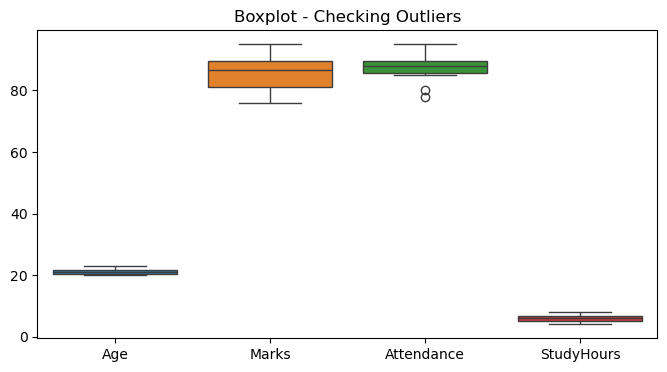

In [12]:
# =====================================================
# STEP 4: Scan for Outliers using Boxplot + IQR Method
# =====================================================

# Visualize outliers using Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[['Age', 'Marks', 'Attendance', 'StudyHours']])
plt.title("Boxplot - Checking Outliers")
plt.show()

In [12]:
# IQR Method to detect and remove outliers in 'Marks'
Q1 = df['Marks'].quantile(0.25)   # 25th percentile
Q3 = df['Marks'].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1                      # Interquartile Range

In [15]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\nIQR for Marks: Q1=", Q1, ", Q3=", Q3, ", IQR=", IQR)
print("Acceptable Range:", lower, "to", upper)


IQR for Marks: Q1= 81.25 , Q3= 89.5 , IQR= 8.25
Acceptable Range: 68.875 to 101.875


In [16]:
# Remove rows where Marks is outside the range
outliers = df[(df['Marks'] < lower) | (df['Marks'] > upper)]
print("\nOutliers Found:")
print(outliers)


Outliers Found:
Empty DataFrame
Columns: [Name, Age, Marks, Attendance, StudyHours, Grade]
Index: []


In [17]:
df = df[(df['Marks'] >= lower) & (df['Marks'] <= upper)]
print("\nDataset After Removing Outliers:")
print(df)


Dataset After Removing Outliers:
      Name   Age  Marks  Attendance  StudyHours Grade
0    Alice  20.0   85.0        90.0         5.0     A
1      Bob  21.0   90.0        85.0         6.0     A
2  Charlie  21.0   78.0        88.0         4.0     B
3    David  22.0   86.5        88.0         7.0     A
4      Eva  20.0   88.0        92.0         5.0     A
5    Frank  23.0   76.0        78.0         6.0     B
6    Grace  21.0   95.0        95.0         8.0     A
7    Henry  21.0   86.5        80.0         4.0     A
8     Isla  22.0   80.0        88.0         6.0     B
9     Jake  20.0   92.0        88.0         7.0     A


In [18]:
# STEP 5: Data Transformation - Min-Max Scaling
# Reason: To convert Marks from 0-100 scale to 0-1 scale
# for better understanding and comparison

df['Marks_scaled'] = (df['Marks'] - df['Marks'].min()) / (df['Marks'].max() - df['Marks'].min())

print("Marks Before and After Scaling:")
print(df[['Marks', 'Marks_scaled']])

Marks Before and After Scaling:
   Marks  Marks_scaled
0   85.0      0.473684
1   90.0      0.736842
2   78.0      0.105263
3   86.5      0.552632
4   88.0      0.631579
5   76.0      0.000000
6   95.0      1.000000
7   86.5      0.552632
8   80.0      0.210526
9   92.0      0.842105


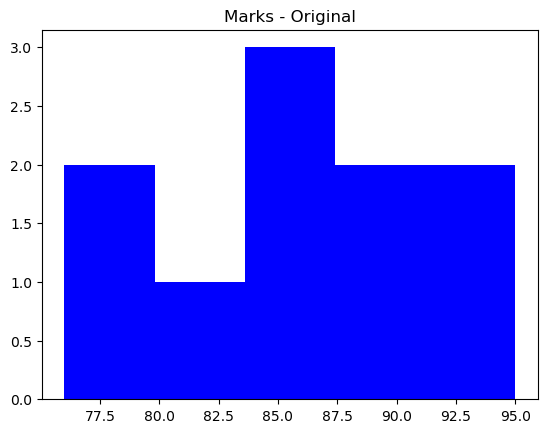

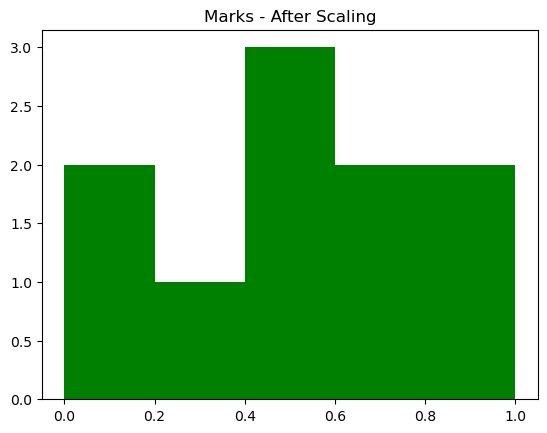

In [20]:
# Before Scaling
plt.hist(df['Marks'], bins=5, color='blue')
plt.title("Marks - Original")
plt.show()

# After Scaling
plt.hist(df['Marks_scaled'], bins=5, color='green')
plt.title("Marks - After Scaling")
plt.show()